In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Day 1.1

In [2]:
depths = np.loadtxt("Day1-input.txt")

In [3]:
def increased(depth, prev_depth):
    if depth > prev_depth:
        return True
    else:
        return False

In [4]:
count = 0
for i in range(len(depths)-1):
    if increased(depths[i+1], depths[i]):
        count+=1

In [5]:
count

1162

# Day 1.2

In [6]:
stride = 3
prev_stride_sum = 0
i =0
count =0
while i < len(depths) - len(depths)%stride:  
    
    stride_sum =0
    k =0
    while k<stride:
        stride_sum += depths[i+k]
        k+=1
        
    if increased(stride_sum, prev_stride_sum) and i>0:
        count+=1
    prev_stride_sum = stride_sum
    i+=1   
    

In [7]:
count

1190

# Day 2.1

In [8]:
lines = open("Day2-input.txt", "r").readlines()

In [9]:
def forward(pos, depth, X ):
    return pos+X, depth

def down(pos, depth , X):
    return pos,depth+X

def up(pos,depth,X):
    return pos,depth-X


In [10]:
pos, depth = 0, 0

for line in lines:
    instruction, str_X = line.split()
    X = int(str_X)
    if instruction == "forward":
        pos,depth = forward(pos,depth, X)
    elif instruction == "down":
        pos,depth = down(pos,depth, X)
    else:
        pos,depth = up(pos,depth,X)


In [11]:
pos*depth

2019945

# Day 2.2

In [12]:
def forward2(pos, depth, aim, X ):
    return pos+X, depth + aim*X, aim

def down2(pos, depth , aim, X):
    return pos, depth, aim+X

def up2(pos,depth, aim, X):
    return pos, depth, aim-X

In [13]:
pos, depth, aim = 0, 0, 0

for line in lines:
    instruction, str_X = line.split()
    X = int(str_X)
    if instruction == "forward":
        pos,depth, aim = forward2(pos,depth,aim, X)
    elif instruction == "down":
        pos,depth, aim = down2(pos,depth, aim, X)
    else:
        pos,depth, aim = up2(pos,depth,aim,X)

In [14]:
pos*depth

1599311480

# Day 3.1

In [15]:
lines = open("Day3-input.txt", "r").readlines()

In [16]:
def binaryTodecimal(binary):
    N = len(binary)
    decimal =0.0
    for i in range(N):
        decimal+= int(binary[i])*2**(N-1-i)
    return decimal

In [17]:
binarys =[]
for line in lines:    
    binary, = line.split()
    binarys.append(binary)

In [18]:
def major_bit(binarys, i):
    num_of_ones = 0
    for k in range(len(binarys)):
        num_of_ones += int(binarys[k][i])
        
    num_of_zeros = len(binarys) - num_of_ones
    
    if num_of_ones >= num_of_zeros:
        return 1
    else:
        return 0

In [19]:
N =12

gamma = np.zeros(N)
epsilon = np.zeros(N)

for i in range(N):
    gamma[i] = major_bit(binarys,i)
    epsilon[i] = 1-gamma[i]

In [20]:
binaryTodecimal(epsilon)* binaryTodecimal(gamma)

3882564.0

# Day 3.2

In [21]:
def o2_bit_search(binarys,i):
    
    #print(i, len(binarys))
    if i > N:
        return []
    
    if len(binarys) == 1:
        return binarys
    
    o2_binarys =[]
    for binary in binarys:
        if int(binary[i]) == major_bit(binarys,i):
            o2_binarys.append(binary)
        
    return o2_bit_search(o2_binarys,i+1)   

def co2_bit_search(binarys,i):    
    #print(i, len(binarys))
    if i > N:
        return []
    
    if len(binarys) == 1:
        return binarys
    
    co2_binarys =[]
    for binary in binarys:
        if int(binary[i]) == 1-major_bit(binarys,i):
            co2_binarys.append(binary)
        
    return co2_bit_search(co2_binarys,i+1)   

In [22]:
o2 = binaryTodecimal(o2_bit_search(binarys,0)[0])
co2 = binaryTodecimal(co2_bit_search(binarys,0)[0])

In [23]:
o2*co2

3385170.0

# DAY 4.1

In [24]:
lines = open("Day4-input.txt", "r").readlines()
drawn_stream = [int(element) for element in lines[0].split(",")]

In [25]:
def mark_num(drawn_number, i):
    if drawn_number in board_list[i]:
        rows, columns = np.where(board_list[i] == drawn_number)
        marker_list[i][rows[0]][columns[0]] = 1 #set it to 1
        

def check_bingo(i):
    
    # check rows
    sum_rows  = np.sum(marker_list[i], axis =1)
    
    if np.any(sum_rows ==5):
        return True
        
    #check columns
    sum_columns  = np.sum(marker_list[i], axis =0)
    if np.any(sum_columns ==5):
        return True
    
    return False


def calculate_score(drawn_number, i):
    
    is_unmarked = marker_list[i] == 0
    sum_unmarked = np.sum(board_list[i][is_unmarked])
    
    return drawn_number*sum_unmarked
    
   
    

In [26]:
#########################
num_boards =0
board =[]
board_list = []
marker_list =[]


for line in lines[2:]:
    if line == '\n':
        num_boards+=1
        board_list.append(np.array(board))
        marker_list.append(np.zeros_like(board))
        #start with making a new board
        board = []
    else:
        board.append([int(element) for element in line.split()])
        
        
board_list.append(np.array(board)) # for the last board
marker_list.append(np.zeros_like(board))



#########################

Bingo = False

c = 0
while Bingo == False:
    
    #draw a number
    drawn_number = drawn_stream[c]
    
    # on all boards
    for i, board in enumerate(board_list):
        #mark_number
        mark_num(drawn_number, i)
        
         #check for bingo
        if c>=4:
            Bingo = check_bingo(i)
            if Bingo:
                print(Bingo)
                winning_score = calculate_score(drawn_number,i)
                print("board_number = " + str(i) + " wins first after " + str(c+1)+ " draws!")
                print("The score is = "+ str(winning_score) )
            
                break
    c+=1
    

True
board_number = 63 wins first after 26 draws!
The score is = 41503


# Day 4.2

In [27]:
#########################
num_boards =0
board =[]
board_list = []
marker_list =[]


for line in lines[2:]:
    if line == '\n':
        num_boards+=1
        board_list.append(np.array(board))
        marker_list.append(np.zeros_like(board))
        #start with making a new board
        board = []
    else:
        board.append([int(element) for element in line.split()])
        
        
board_list.append(np.array(board)) # for the last board
marker_list.append(np.zeros_like(board))
#########################

Bingo = False


c = 0

winners = np.zeros(100)

while np.sum(winners)<=99:
    
    #draw a number
    drawn_number = drawn_stream[c]
    
    # on all boards
    for i, board in enumerate(board_list):
        #mark_number
        mark_num(drawn_number, i)
        
         #check for bingo
        if c>=4 and winners[i] == 0: #no wins yet
            Bingo = check_bingo(i)
            if Bingo:
                winners[i] =1 
                winning_score = calculate_score(drawn_number,i)
                
    c+=1

In [28]:
winning_score

3178

# Day 5.1 and 5.2

In [29]:
data_lines = open("Day5-input.txt", "r").readlines()
#drawn_stream = [int(element) for element in lines[0].split(",")]

In [30]:
def is_horizontal(start, stop):
    if start[0] == stop[0]:
        return True
    return False

def is_vertical(start, stop):
    if start[1] == stop[1]:
        return True
    return False

def is_diagonal(start, stop):
    angle = np.arctan((stop[1]-start[1])/(stop[0]-start[0]))
    if np.abs(angle) == np.pi/4 :
        return True
    return False

In [31]:
points = []
for l in data_lines[:]:
    start = [int(element) for element in l.split()[0].split(",")]
    stop = [int(element) for element in l.split()[2].split(",")]

    if is_horizontal(start, stop):  
            
        x = start[0]
        if start[1] > stop[1]:
            start, stop = stop, start #swap
            
        for y in range(start[1], stop[1]+1):
            points.append((x,y))  
            
    elif is_vertical(start, stop):
        y = start[1]
        if start[0] > stop[0]:
            start, stop = stop, start #swap
            
        for x in range(start[0], stop[0]+1):
            points.append((x,y))
            
    elif is_diagonal(start, stop):
        
        if start[0] > stop[0]:
            x_list = list(range(start[0], stop[0]-1, -1))
        else:
            x_list = list(range(start[0], stop[0]+1, 1))
        
        

        if start[1] > stop[1]:
            y_list = list(range(start[1], stop[1]-1, -1))
        else:
            y_list = list(range(start[1], stop[1]+1, 1))
      
        points.extend(list(zip(x_list,y_list)))
            

    

In [32]:
from collections import Counter
intersections = np.array(list(Counter(points).values()))

print(np.where(intersections>1)[0].size)

22088


# Day 6.1

In [33]:
data_lines = open("Day6-input.txt", "r").readlines()

In [34]:
def update_day(state, i):
    
    if state[i] == 0:
        state[i] = 6
        state.append(8) #reproduce
    else:
        state[i]-=1
    return state 

In [35]:
num_of_days = 80
initial_state = [int(element) for element in data_lines[0].split(",")] #list

days = 0
while days < num_of_days:
    
    for i in range(len(initial_state)):
        updated_state = update_day(initial_state, i)
    initial_state = updated_state
    #print(initial_state)
    days+=1
    

In [36]:
len(initial_state)

386640

# Day 6.2  (more efficient)

In [37]:
days =0
num_of_days = 256
initial_state = np.array([int(element) for element in data_lines[0].split(",")]) #array
initial_ages = np.array([np.count_nonzero(initial_state ==0),
                np.count_nonzero(initial_state ==1),
                np.count_nonzero(initial_state ==2),
                np.count_nonzero(initial_state ==3),
                np.count_nonzero(initial_state ==4),
                np.count_nonzero(initial_state ==5),
                np.count_nonzero(initial_state ==6),
                np.count_nonzero(initial_state ==7),
                np.count_nonzero(initial_state ==8)
               ])

while days < num_of_days:
    initial_ages = np.array([initial_ages[(i + 1) % len(initial_ages)]
            for i, x in enumerate(initial_ages)]) #rotate ages to make parents babies
    initial_ages[6]+= initial_ages[8] # add the number of parents to the list at day 6
    days+=1

In [38]:
np.sum(initial_ages) 

1733403626279

# Day 7.1

In [39]:
data_lines = open("Day7-input.txt", "r").readlines()

In [40]:
#crab_positions = np.array([16,1,2,0,4,2,7,1,2,14])
crab_positions = np.array([int(element) for element in data_lines[0].split(",")])
fuel_spent = []
for center in range(min(crab_positions), max(crab_positions)+1):   
    fuel_spent.append(np.sum(np.abs(crab_positions -center)))
   

In [41]:
np.min(np.array(fuel_spent))

340987

In [42]:
def cumsum(n):
    return n*(n+1)/2

In [43]:
crab_positions = np.array([int(element) for element in data_lines[0].split(",")])
fuel_spent = []
for center in range(min(crab_positions), max(crab_positions)+1):   
    fuel_spent.append(np.sum(cumsum(np.abs(crab_positions -center))))
   

In [44]:
np.where(fuel_spent == np.min(np.array(fuel_spent)))

(array([478]),)

In [45]:
np.min(np.array(fuel_spent))

96987874.0

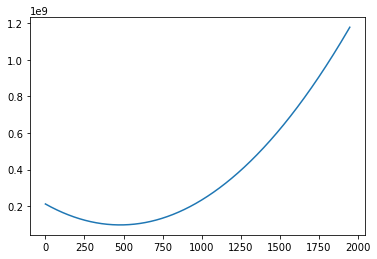

In [48]:
plt.plot(fuel_spent)

# Day 8.1

In [350]:
len_dict = { "0": 6,
            "1": 2, #unique
            "2": 5,
            "3": 5,
            "4": 4,#unique
            "5": 5,
            "6": 6,
            "7": 3,#unique
            "8": 7,#unique
            "9": 6 }
count_list = np.zeros(10)

In [351]:
data_lines = open("Day8-input.txt", "r").readlines()

In [352]:
total_u_digits =0
for line in data_lines:
    #print(line)
    pos =0
    start_flag = False
    
    while(line[pos] != '\n'): 
        #till you reach the end of the line
        char = line[pos]
        if char == '|':
            start_flag = True
            len_count = 0
            
        if char != '!' and start_flag:
            if char != ' ':
                len_count +=1
                #print(char)
            else:
                #print(len_count)
                if len_count == 2 or len_count ==4 or len_count ==3 or len_count ==7:
                    total_u_digits+=1
                len_count =0
                
        pos+=1      
    
    if len_count == 2 or len_count ==4 or len_count ==3 or len_count ==7:
            total_u_digits+=1
            len_count =0
    
            
            
                

In [353]:
total_u_digits

264

# Day 8.2

In [354]:
def decoding_dict(lst  # array
           ):   
    
    len_lst = np.array(list(map(lambda word : len(word), lst)))
    
    seg_dict = {}
    
    seg_dict["1"] = lst[len_lst ==2][0]
    seg_dict["4"] = lst[len_lst ==4][0]
    seg_dict["7"] = lst[len_lst ==3][0]
    seg_dict["8"] = lst[len_lst ==7][0]
    seg_dict["6"] = [ word for word in lst[len_lst ==6] if any(char not in word for char in seg_dict["1"])][0]
    seg_dict["9"] = [ word for word in lst[len_lst ==6] if word != seg_dict["6"] and all(char in word for char in seg_dict["4"])][0]
    seg_dict["0"] = [ word for word in lst[len_lst ==6] if word != seg_dict["9"] and word != seg_dict["6"]][0]
    seg_dict["3"] = [ word for word in lst[len_lst ==5] if all(char in word for char in seg_dict["1"])][0]
    seg_dict["5"] = [ word for word in lst[len_lst ==5] if all(char in seg_dict["6"] for char in word)][0]
    seg_dict["2"] = [ word for word in lst[len_lst ==5] if word != seg_dict["3"] and word != seg_dict["5"]][0]    
    return(seg_dict)
    

In [355]:
total_decoded =0
for line in data_lines:    
    seg_dict = decoding_dict(np.array(line.split()[0:10]))
    
    decoded = [ [list(seg_dict.keys())[index] for index, value in enumerate(seg_dict.values()) if sorted(word) == sorted(value)][0]
                     for word in line.split()[11:]]
    #print(int(''.join(decoded)))
    total_decoded += int(''.join(decoded))

In [356]:
total_decoded 

1063760

# Day 9.1

In [471]:
data_lines = open("Day9-input.txt", "r").readlines()

In [472]:
heightmap_lst = []
for line in data_lines:
    heightmap_lst.append(list(line[:-1]))
heightmap = np.array(heightmap_lst)

In [473]:
heightmap.shape

(100, 100)

In [474]:
def is_lowPoint(i,j):
    if i!=0 and int(heightmap[i,j])>= int(heightmap[i-1,j]):
        #print("up")
        return False
    elif j!=0 and int(heightmap[i,j])>= int(heightmap[i,j-1]):
        #print("left")
        return False
    elif i!=heightmap.shape[0]-1 and int(heightmap[i,j])>= int(heightmap[i+1,j]):
        #print("down")
        return False
    elif j!=heightmap.shape[1]-1 and int(heightmap[i,j])>= int(heightmap[i,j+1]):
        #print("right")
        return False
    else:
        return True
            

In [540]:
low_points = []
img_arr = np.ones(heightmap.shape)
sum_scores = 0
for i in range((heightmap).shape[0]):
    for j in range((heightmap).shape[1]):
        #print(i,j)
        if is_lowPoint(i,j):
            low_points.append([i,j])
            
            #print("low",heightmap[i,j])
            sum_scores+= int(heightmap[i,j])+1
            
        if int(heightmap[i,j])==9:
            img_arr[i,j] =0

In [541]:
sum_scores

545

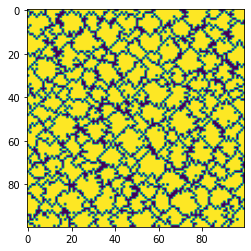

In [542]:
plt.imshow(img_arr)

# Day 9.2

In [582]:
#recursive
def explore_basin(i,j, basin):
    if i!=0 and int(heightmap[i-1,j]) != 9:
        if [i-1,j] not in basin:
            basin.append([i-1,j])
            explore_basin(i-1,j,basin)
    if j!=0 and int(heightmap[i,j-1])!=9:
        if [i,j-1] not in basin:
            basin.append([i,j-1])
            explore_basin(i,j-1,basin)
    if i!=heightmap.shape[0]-1 and  int(heightmap[i+1,j])!=9:
        if [i+1,j] not in basin:
            basin.append([i+1,j])
            explore_basin(i+1,j,basin)
    if j!=heightmap.shape[1]-1 and  int(heightmap[i,j+1])!=9:
        if [i,j+1] not in basin:
            basin.append([i,j+1])
            explore_basin(i,j+1,basin)
    return basin

In [583]:
basin_sizes = []
for point in low_points:
    basin_sizes.append(len(explore_basin(point[0],point[1], basin = [])))

In [584]:
sorted_basin_sizes = sorted(basin_sizes)[::-1]

In [585]:
sorted_basin_sizes[0]*sorted_basin_sizes[1]*sorted_basin_sizes[2]

950600

# Day 10.1

In [650]:
data_lines = open("Day10-input.txt", "r").readlines()

In [651]:
#data_lines = ['[[<[([]))<([[{}[[()]]]']

In [670]:
bra_dict = {
                "(":0,
                "[":0,
                "{":0,
                "<":0}
ket_dict ={
                ")":0,
                "]":0,
                "}":0,
                ">":0
                }

score_dict = {
                ")":3,
                "]":57,
                "}":1197,
                ">":25137   
            }

AC_score_dict = {
                ")":1,
                "]":2,
                "}":3,
                ">":4   
            }


braket_dict = dict(zip(bra_dict.keys(), ket_dict.keys()))


In [671]:
def match(bra, ket):
    if braket_dict[bra] == ket:
        return True
    return False

In [672]:
err_score = 0
for line in data_lines[:]:
    bra_list =[]
    #check fot corruption
    pos = 0
    char = line[pos]
    while(char != '\n'):  
        #print(char)
        if char in bra_dict.keys():
            bra_list.append(char)
        else:
            if match(bra_list[-1], char):
                bra_list.pop()
            else:
                #corrupted line
                print("Expected "+ braket_dict[bra_list[-1]] + " but found " +char+ " instead!")
                err_score+= score_dict[char]
                break
        pos+=1
        char = line[pos]
    

Expected ) but found ] instead!
Expected ) but found ] instead!
Expected ) but found } instead!
Expected ) but found ] instead!
Expected ] but found } instead!
Expected ) but found > instead!
Expected ) but found ] instead!
Expected ) but found > instead!
Expected } but found > instead!
Expected } but found > instead!
Expected } but found ) instead!
Expected } but found > instead!
Expected } but found ] instead!
Expected } but found > instead!
Expected } but found ) instead!
Expected > but found } instead!
Expected > but found } instead!
Expected ) but found > instead!
Expected } but found ) instead!
Expected } but found ) instead!
Expected ) but found ] instead!
Expected ] but found } instead!
Expected } but found > instead!
Expected > but found ] instead!
Expected ) but found > instead!
Expected ) but found > instead!
Expected ] but found } instead!
Expected } but found ) instead!
Expected } but found > instead!
Expected > but found ) instead!
Expected } but found ) instead!
Expected

In [673]:
err_score

392367

# Part 10.2

In [684]:
AC_scores =[]
for line in data_lines[:]:
    AC_score = 0
    bra_list =[]
    corruption_flag = False
    #check fot corruption
    pos = 0
    char = line[pos]
    while(char != '\n'):  
        #print(char)
        if char in bra_dict.keys():
            bra_list.append(char)
        else:
            if match(bra_list[-1], char):
                bra_list.pop()
            else:
                #corrupted line
                corruption_flag = True
                #print("Expected "+ braket_dict[bra_list[-1]] + " but found " +char+ " instead!")
                #err_score+= score_dict[char]
                break
        pos+=1
        char = line[pos]
    
    if bra_list!= [] and corruption_flag == False:
        #print(bra_list)
        while bra_list !=[]:
            AC_score = 5*AC_score + AC_score_dict[braket_dict[bra_list.pop()]]
    
        AC_scores.append(AC_score)
            
        

In [694]:
sorted(AC_scores)[int(np.floor((len(AC_scores)-1)/2))]

2192104158

# Day 11.1

In [933]:
data_lines = open("Day11-input-test.txt", "r").readlines()

In [934]:
octomap_lst = []
for line in data_lines:
    octomap_lst.append(list(line[:-1]))

In [935]:
def flash(i,j,flashed_octopuses):
    
    if [i,j] not in flashed_octopuses:
        flashed_octopuses.append([i,j])
        octomap[i,j] = 0 
        
        get_neighbors():
            
        
        
        if i!=0: #up
            
            octomap[i-1,j]+=1
            if octomap[i-1,j] ==9 and [i-1,j] not in flashed_octopuses:
                flash(i-1,j,flashed_octopuses)
                
        
        if j!=0: #left
            octomap[i,j-1]+=1
            if octomap[i,j-1] ==9 and [i,j-1] not in flashed_octopuses:
                flash(i,j-1,flashed_octopuses)
        if i!=octomap.shape[0]-1: #down
            octomap[i+1,j]+=1
            if octomap[i+1,j] ==9 and [i+1,j] not in flashed_octopuses:                
                flash(i+1,j,flashed_octopuses)            
        if j!=octomap.shape[1]-1: #right
            octomap[i,j+1]+=1
            if octomap[i,j+1]==9 and [i,j+1] not in flashed_octopuses:
                flash(i,j+1,flashed_octopuses) 
        
            
    return flashed_octopuses

In [939]:
def get_neighbors(i,j):
    for ii in range(i-,i+1):
        for jj in range(j-1, j+1):
            print(ii,jj)

    
    

In [941]:
get_neighbors(2,2)

1 1
1 2
2 1
2 2


In [937]:
octomap = np.array(octomap_lst, dtype = int)

total_flashes=0
num_steps = 0

while(num_steps<5):
    print(octomap)
    flashed_octopuses =[]
    octomap+=1
    x,y = np.where(octomap == 9)
    for i,j in zip(x,y):
        flashed_octopuses = flash(i,j,flashed_octopuses)
    total_flashes += len(flashed_octopuses)
    
    num_steps+=1

[[5 4 8 3 1 4 3 2 2 3]
 [2 7 4 5 8 5 4 7 1 1]
 [5 2 6 4 5 5 6 1 7 3]
 [6 1 4 1 3 3 6 1 4 6]
 [6 3 5 7 3 8 5 4 7 8]
 [4 1 6 7 5 2 4 6 4 5]
 [2 1 7 6 8 4 1 7 2 1]
 [6 8 8 2 8 8 1 1 3 4]
 [4 8 4 6 8 4 8 5 5 4]
 [5 2 8 3 7 5 1 5 2 6]]
[[6 6 0 5 3 5 4 3 3 4]
 [3 8 6 7 0 7 5 8 2 2]
 [6 3 7 5 7 6 7 2 8 4]
 [7 2 5 3 4 5 7 2 6 8]
 [7 4 8 0 6 0 7 6 0 1]
 [5 3 0 2 8 4 5 7 6 7]
 [3 4 2 1 2 7 2 8 3 2]
 [8 2 1 6 2 0 4 2 4 5]
 [6 0 8 8 1 8 0 7 6 5]
 [6 5 0 6 0 7 3 6 3 7]]
[[7 8 1 6 4 6 5 5 4 5]
 [5 0 8 8 1 8 7 0 5 3]
 [7 5 8 6 8 7 8 5 1 7]
 [8 3 7 4 5 6 8 4 0 1]
 [8 6 0 2 8 1 8 8 2 3]
 [6 4 2 4 0 6 7 0 8 8]
 [5 5 3 2 4 8 4 1 5 3]
 [0 4 3 8 3 2 5 4 5 6]
 [8 2 1 0 4 1 2 8 7 6]
 [7 6 2 8 2 0 5 7 4 8]]
[[0 1 4 8 5 8 7 6 5 6]
 [8 3 2 1 5 2 1 2 6 4]
 [0 8 2 1 1 3 1 7 2 8]
 [2 6 0 8 0 1 2 7 1 2]
 [0 8 2 4 1 6 2 0 5 5]
 [8 5 3 5 3 0 1 4 1 0]
 [6 6 4 4 6 1 7 2 7 5]
 [2 5 5 0 5 4 6 6 7 8]
 [1 4 2 3 5 2 4 2 1 0]
 [0 8 4 0 4 1 7 0 8 1]]
[[2 2 6 0 8 1 0 8 6 7]
 [0 6 3 3 6 4 3 3 7 6]
 [3 1 4 3 2 4 2 8 4 0]
 [4 0 3

In [938]:
total_flashes

96